In [6]:
import yaml
import torch
import numpy as np
from dotmap import DotMap
import matplotlib.pyplot as plt

# Use matplotlib's tex rendering
import matplotlib
matplotlib.rcParams['text.usetex'] = True

from pud.algos.ddpg import GoalConditionedCritic
from pud.visualizers.visualize import plot_agent_paths
from pud.utils import set_global_seed, set_env_seed
from pud.algos.lagrange.drl_ddpg_lag import DRLDDPGLag
from pud.algos.policies import ConstrainedMultiAgentSearchPolicy
from pud.collectors.constrained_collector import ConstrainedCollector
from pud.envs.safe_pointenv.pb_sampler import load_pb_set, sample_pbs_by_agent
from pud.envs.safe_pointenv.safe_wrappers import SafeGoalConditionedPointBlendWrapper, SafeGoalConditionedPointQueueWrapper, SafeGoalConditionedPointWrapper, safe_env_load_fn

#### Load the evaluation configuration

In [7]:
unconstrained_ckpt_file = "models/CenterDot/ckpt/ckpt_0300000"
config_file = "models/CenterDot/lag/2024-07-30-21-31-48/bk/bk_config.yaml"
constrained_ckpt_file = "models/CenterDot/lag/2024-07-30-21-31-48/ckpt/ckpt_0600000"
illustration_pb_file = "pud/envs/safe_pointenv/illustration_set/CenterDot_resize_3_linear_r3_4pts.txt"

with open(config_file, 'r') as f:
    config = yaml.safe_load(f)
config = DotMap(config)

# User defined parameters for evaluation
config.device = "cuda:0"
config.agent.cost_limit = 1.5
config.replay_buffer.max_size = 1000

set_global_seed(config.seed)

#### Load the evaluation environment

In [8]:
gym_env_wrappers = []
gym_env_wrapper_kwargs = []
for wrapper_name in config.wrappers:
    if wrapper_name == "SafeGoalConditionedPointWrapper":
        gym_env_wrappers.append(SafeGoalConditionedPointWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())
    elif wrapper_name == "SafeGoalConditionedPointBlendWrapper":
        gym_env_wrappers.append(SafeGoalConditionedPointBlendWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())
    elif wrapper_name == "SafeGoalConditionedPointQueueWrapper":
        gym_env_wrappers.append(SafeGoalConditionedPointQueueWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())

eval_env = safe_env_load_fn(
    config.env.toDict(),
    config.cost_function.toDict(),
    max_episode_steps=config.time_limit.max_episode_steps,
    gym_env_wrappers=gym_env_wrappers,
    wrapper_kwargs=gym_env_wrapper_kwargs,
    terminate_on_timeout=True,
)

set_env_seed(eval_env, config.seed + 2)

[INFO] skipping the reset in PointEnv.__init__ because setup is not ready yet
[INFO] PointEnv setup: 0.016577720642089844 s
[INFO] SafePointEnv setup: 0.0025742053985595703 s


/scratch/miniconda3/envs/cc-sorb/lib/python3.9/site-packages/gym/spaces/box.py:128: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/scratch/miniconda3/envs/cc-sorb/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/scratch/miniconda3/envs/cc-sorb/lib/python3.9/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


#### Load the inference agent

In [9]:
obs_dim = eval_env.observation_space['observation'].shape[0]  # type: ignore
goal_dim = obs_dim
state_dim = obs_dim + goal_dim
action_dim = eval_env.action_space.shape[0]  # type: ignore
max_action = float(eval_env.action_space.high[0])  # type: ignore
print(f'Obs dim: {obs_dim},\n'
      f'Goal dim: {goal_dim},\n'
      f'State dim: {state_dim},\n'
      f'Action dim: {action_dim},\n'
      f'Max action: {max_action}')

agent = DRLDDPGLag(
        state_dim,  # Concatenating obs and goal
        action_dim,
        max_action,
        CriticCls=GoalConditionedCritic,
        device=torch.device(config.device),
        **config.agent,
    )

agent.load_state_dict(torch.load(constrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

Obs dim: 2,
Goal dim: 2,
State dim: 4,
Action dim: 2,
Max action: 1.0


DRLDDPGLag(
  (actor): GoalConditionedActor(
    (l1): Linear(in_features=4, out_features=256, bias=True)
    (l2): Linear(in_features=256, out_features=256, bias=True)
    (l3): Linear(in_features=256, out_features=2, bias=True)
  )
  (actor_target): GoalConditionedActor(
    (l1): Linear(in_features=4, out_features=256, bias=True)
    (l2): Linear(in_features=256, out_features=256, bias=True)
    (l3): Linear(in_features=256, out_features=2, bias=True)
  )
  (critic): EnsembledCritic(
    (critics): ModuleList(
      (0-2): 3 x GoalConditionedCritic(
        (l1): Linear(in_features=4, out_features=256, bias=True)
        (l2): Linear(in_features=258, out_features=256, bias=True)
        (l3): Linear(in_features=256, out_features=20, bias=True)
      )
    )
  )
  (critic_target): EnsembledCritic(
    (critics): ModuleList(
      (0-2): 3 x GoalConditionedCritic(
        (l1): Linear(in_features=4, out_features=256, bias=True)
        (l2): Linear(in_features=258, out_features=256, b

#### Sample a replay buffer to form our search graph

In [10]:
rb_vec = ConstrainedCollector.sample_initial_unconstrained_states(eval_env, config.replay_buffer.max_size)

agent.load_state_dict(torch.load(unconstrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()
pdist = agent.get_pairwise_dist(rb_vec, aggregate=None)  # type: ignore

agent.load_state_dict(torch.load(constrained_ckpt_file))
pcost = agent.get_pairwise_cost(rb_vec, aggregate=None)  # type: ignore

#### Sample (start, goal) problems for the agent

In [ ]:
if len(illustration_pb_file) > 0:
    problems = load_pb_set(file_path=illustration_pb_file, env=eval_env, agent=agent)  # type: ignore
else:
    problems = sample_pbs_by_agent(
        K=10,
        min_dist=0,
        agent=agent,  # type: ignore
        env=eval_env,  # type: ignore
        target_val=10,
        num_states=100,
        ensemble_agg="mean",
        use_uncertainty=False,
        max_dist=eval_env.max_goal_dist,  # type: ignore
    )
    assert len(problems) > 0

eval_env.set_use_q(True)  # type: ignore
eval_env.set_prob_constraint(1.0)  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

agent.to(torch.device(config.device))
agent.eval()

DRLDDPGLag(
  (actor): GoalConditionedActor(
    (l1): Linear(in_features=4, out_features=256, bias=True)
    (l2): Linear(in_features=256, out_features=256, bias=True)
    (l3): Linear(in_features=256, out_features=2, bias=True)
  )
  (actor_target): GoalConditionedActor(
    (l1): Linear(in_features=4, out_features=256, bias=True)
    (l2): Linear(in_features=256, out_features=256, bias=True)
    (l3): Linear(in_features=256, out_features=2, bias=True)
  )
  (critic): EnsembledCritic(
    (critics): ModuleList(
      (0-2): 3 x GoalConditionedCritic(
        (l1): Linear(in_features=4, out_features=256, bias=True)
        (l2): Linear(in_features=258, out_features=256, bias=True)
        (l3): Linear(in_features=256, out_features=20, bias=True)
      )
    )
  )
  (critic_target): EnsembledCritic(
    (critics): ModuleList(
      (0-2): 3 x GoalConditionedCritic(
        (l1): Linear(in_features=4, out_features=256, bias=True)
        (l2): Linear(in_features=258, out_features=256, b

: 

## Single-Agent Comparisons

### Constrained Low-Level Policy with Graph Search

In [ ]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "edge_attributes": ["step"],
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=1,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    max_cost_limit=0.5 * config.agent.cost_limit,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

start, goal, constrained_search_observations, constrained_search_waypoints, _, constrained_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

### Lagrangian Graph Search

In [ ]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "edge_attributes": ["step", "cost"],
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 60,
    "lagrangian": agent.lagrange.lagrangian_multiplier.data.numpy(),
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=1,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

start, goal, lagrangian_search_observations, lagrangian_search_waypoints, _, lagrangian_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

### Biobjective Search

In [ ]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": False,
    "collision_radius": 0.0,
    "use_cardinality": False,
    "risk_attribute": "cost",
    "use_multi_objective": True,
    "split_strategy": "disjoint",
    "edge_attributes": ["step", "cost"],
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/bocbs",
}

search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=1,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

start, goal, biobjective_search_observations, biobjective_search_waypoints, _, biobjective_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

First solution time (s):  20.735728979110718


### Collect Bounds (Needed to compute bounds for $\Delta$) 

In [ ]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "lb_save_path": "pud/plots/exps/lb_centerdot.npy",
    "ub_save_path": "pud/plots/exps/ub_centerdot.npy",
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=1,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    max_cost_limit=np.inf,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

cbs_config["edge_attributes"] = ["cost"]
start, goal, _, _, _, _ = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

cbs_config["edge_attributes"] = ["step"]
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore
start, goal, _, _, _, _ = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)
bounds_data = {"cbs": {}, "lb": None, "ub": None}
cbs_lb = np.load(cbs_config["lb_save_path"])
cbs_ub = np.load(cbs_config["ub_save_path"])
bounds_data["cbs"]["lb"] = cbs_lb[-1]
bounds_data["cbs"]["ub"] = cbs_ub[-1]

NameError: name 'eval_env' is not defined

In [ ]:
def compute_search_cost(waypoints, goals, agent):
    total_cost = 0.0
    for idx, wps in enumerate(waypoints):
        for i in range(len(wps)):
            if i == 0:
                continue
            prev_wp = wps[i - 1]
            curr_wp = wps[i]
            if (prev_wp == goals[idx]).all():
                continue
            edge_cost = agent.get_pairwise_cost([prev_wp], [curr_wp], aggregate="min")[0][0]
            total_cost += edge_cost
    return total_cost

### Risk Bounded Search with Uniform Allocater

In [ ]:
RISK_PERCENTAGES = [0.0, 0.05, 0.25, 0.50]
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "budget_allocater": "uniform",
    "edge_attributes": ["step", "cost"],
    "risk_reallocation_strategy": "price_clearing",
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/rbcbs",
}

search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=1,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    max_cost_limit=np.inf,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

cbs_config["risk_bound"] = bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[0] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"])

start, goal, rbu_search_observations_0, rbu_search_waypoints_0, _, rbu_search_records_0 = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

Time to find paths:  0.02046680450439453


In [ ]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config["risk_bound"] = bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[1] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"])

start, goal, rbu_search_observations_1, rbu_search_waypoints_1, _, rbu_search_records_1 = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

Time to find paths:  1.2259116172790527


In [ ]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config["risk_bound"] = bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[2] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"])

start, goal, rbu_search_observations_2, rbu_search_waypoints_2, _, rbu_search_records_2 = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

Time to find paths:  0.07594847679138184


In [ ]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config["risk_bound"] = bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[3] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"])

start, goal, rbu_search_observations_3, rbu_search_waypoints_3, _, rbu_search_records_3 = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

#### Plot the single-agent comparison

In [ ]:
constrained_search_observations = np.array(constrained_search_observations)
lagrangian_search_observations = np.array(lagrangian_search_observations)
biobjective_search_observations = np.array(biobjective_search_observations)
rbu_search_observations_0 = np.array(rbu_search_observations_0)
rbu_search_observations_1 = np.array(rbu_search_observations_1)
rbu_search_observations_2 = np.array(rbu_search_observations_2)
rbu_search_observations_3 = np.array(rbu_search_observations_3)

constrained_search_waypoints = np.array(constrained_search_waypoints)
lagrangian_search_waypoints = np.array(lagrangian_search_waypoints)
biobjective_search_waypoints = np.array(biobjective_search_waypoints)
rbu_search_waypoints_0 = np.array(rbu_search_waypoints_0)
rbu_search_waypoints_1 = np.array(rbu_search_waypoints_1)
rbu_search_waypoints_2 = np.array(rbu_search_waypoints_2)
rbu_search_waypoints_3 = np.array(rbu_search_waypoints_3)

<>:15: DeprecationWarning: invalid escape sequence \%


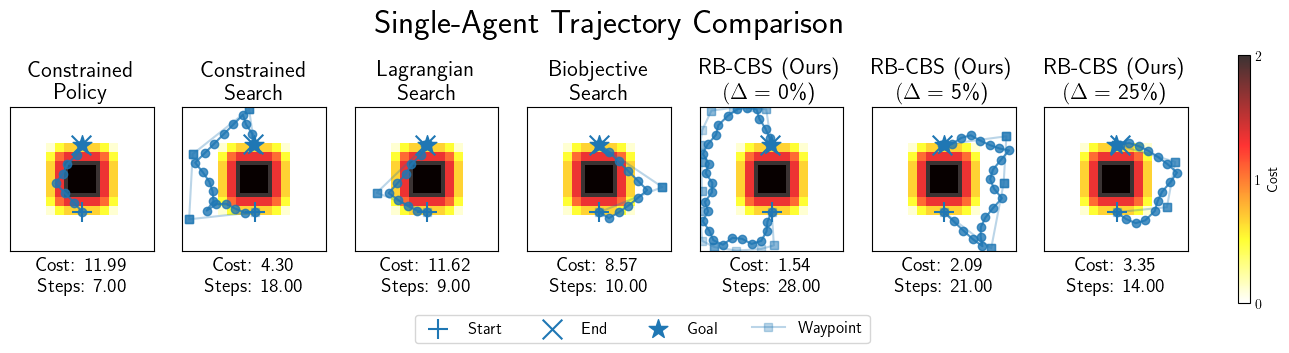

In [ ]:
fig, axs = plt.subplots(1, 7, figsize=(16, 3.5))

for ax in axs.flat:
    ax.imshow(eval_env.get_map(), cmap="binary", interpolation="nearest", alpha=1.0, extent=[0, 1, 0, 1])
    cmap = ax.imshow(eval_env.get_cost_map(), cmap="hot_r", interpolation="nearest", alpha=0.8, extent=[0, 1, 0, 1])
    ax.set_xticks([])
    ax.set_yticks([])

cbar = plt.colorbar(cmap, ax=axs, orientation="vertical", fraction=0.01, pad=0.04)
cbar.ax.tick_params(size=0)
cbar.set_ticks([0, 1, 2])

deltas = [bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[i] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"]) for i in range(len(RISK_PERCENTAGES))]
delta_strings = [f"{deltas[i]:.2f}" for i in range(len(deltas))]
delta_percents = [f"{RISK_PERCENTAGES[i] * 100:.0f}\%" for i in range(len(RISK_PERCENTAGES))]  # type: ignore

methods_records_map = {
    "Constrained\nSearch": (constrained_search_records, constrained_search_observations, constrained_search_waypoints),
    "Lagrangian\nSearch": (lagrangian_search_records, lagrangian_search_observations, lagrangian_search_waypoints),
    "Biobjective\nSearch": (biobjective_search_records, biobjective_search_observations, biobjective_search_waypoints),
    "WALRIS (Ours)\n 1": (rbu_search_records_0, rbu_search_observations_0, rbu_search_waypoints_0),
    "WALRIS (Ours)\n 2": (rbu_search_records_1, rbu_search_observations_1, rbu_search_waypoints_1),
    "WALRIS (Ours)\n 3": (rbu_search_records_2, rbu_search_observations_2, rbu_search_waypoints_2),
    "WALRIS (Ours)\n 4": (rbu_search_records_3, rbu_search_observations_3, rbu_search_waypoints_3),  # type: ignore
}
titles = methods_records_map.keys()

def calculate_costs_and_rewards(records, waypoints=None):
    cc = sum([record["cumulative_costs"] for record in records])
    if waypoints is not None:
        cc = compute_search_cost(waypoints, goal, agent)
    reward = np.mean([record["rewards"] for record in records])
    return cc, reward

agent_id = 0  # We are only plotting for a single agent
for ax, title in zip(axs.flat, list(titles)):
    ax = plot_agent_paths(
        agent_id,
        start[agent_id],
        goal[agent_id],
        methods_records_map[title][1][agent_id],
        title,
        ax,
        wps=methods_records_map[title][2][agent_id] if "Search" in title or "Ours" in title else None,
        use_agent_id=False
    )
    if "Ours" in title:
        ax.set_title(title[:-2] + r"$(\Delta=$ " + delta_percents.pop(0) + ")", fontsize=16)
        # ax.set_title(title[:-2] + " (" + delta_percents.pop(0) + ")", fontsize=16)  # type: ignore
    # cc, reward = calculate_costs_and_rewards(methods_records_map[title][0], 
    #                                          methods_records_map[title][2] if "Search" in title else None)
    cc, reward = calculate_costs_and_rewards(methods_records_map[title][0])
    ax.text(0.5, -0.1, f"Cost: {cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=ax.transAxes, weight='bold', fontsize=14)
    ax.text(0.5, -0.25, f"Steps: {abs(reward):.2f}", horizontalalignment="center", verticalalignment="center", transform=ax.transAxes, weight='bold', fontsize=14)

cbar.set_label("Cost")
plt.legend(loc="lower center", bbox_to_anchor=(-2.8, -0.7), ncol=4, fontsize=12)
_ = plt.suptitle("Single-Agent Trajectory Comparison", fontsize=24)
# plt.savefig("pud/plots/figures/paper/safe_single_agent_pointenv_comparison.svg", bbox_inches="tight")

## Multi-Agent Comparisons

### Constrained Low-Level Policy

In [18]:
n_agents = 4
problems = [problems[0], problems[1], problems[5], problems[7]]
agent.to(torch.device(config.device))
agent.eval()

eval_env.set_pbs(pb_list=problems.copy())  # type: ignore
start, goal, constrained_observations, _, _, constrained_records = ConstrainedCollector.get_trajectories(agent, eval_env, n_agents)

### Constrained Low-Level Policy with Graph Search

In [19]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "edge_attributes": ["step"],
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=n_agents,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    max_cost_limit=0.5 * config.agent.cost_limit,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

start, goal, constrained_search_observations, constrained_search_waypoints, _, constrained_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

Time to find paths:  0.12514519691467285


### Lagrangian Graph Search

In [20]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "edge_attributes": ["step", "cost"],
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 60,
    "lagrangian": agent.lagrange.lagrangian_multiplier.data.numpy(),
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=n_agents,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

start, goal, lagrangian_search_observations, lagrangian_search_waypoints, _, lagrangian_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

Time to find paths:  0.03471183776855469


### Biobjective Search

In [21]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": False,
    "collision_radius": 0.0,
    "use_cardinality": False,
    "risk_attribute": "cost",
    "use_multi_objective": True,
    "split_strategy": "disjoint",
    "edge_attributes": ["step", "cost"],
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 120,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/bocbs",
}

search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=n_agents,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

start, goal, biobjective_search_observations, biobjective_search_waypoints, _, biobjective_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

First solution time (s):  118.66249895095825
Time to find paths:  121.13947629928589


### Collect Bounds (Needed to compute bounds for $\Delta$)

In [22]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "lb_save_path": "pud/plots/exps/lb_centerdot.npy",
    "ub_save_path": "pud/plots/exps/ub_centerdot.npy",
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=n_agents,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    max_cost_limit=np.inf,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

cbs_config["edge_attributes"] = ["cost"]
start, goal, _, _, _, _ = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

cbs_config["edge_attributes"] = ["step"]
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore
start, goal, _, _, _, _ = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=False,
    wait=True,
    threshold=1e-3,
)
bounds_data = {"cbs": {}, "lb": None, "ub": None}
cbs_lb = np.load(cbs_config["lb_save_path"])
cbs_ub = np.load(cbs_config["ub_save_path"])
bounds_data["cbs"]["lb"] = cbs_lb[-1]
bounds_data["cbs"]["ub"] = cbs_ub[-1]

Time to find paths:  1.1462445259094238
Time to find paths:  0.03233909606933594


### Risk Bounded Search with Uniform Allocater

In [23]:
RISK_PERCENTAGES = [0.0, 0.05, 0.25]
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "budget_allocater": "uniform",
    "edge_attributes": ["step", "cost"],
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 120,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/rbcbs",
}

search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=n_agents,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    max_cost_limit=np.inf,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

cbs_config["risk_bound"] = bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[0] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"])

start, goal, rbu_search_observations_0, rbu_search_waypoints_0, _, rbu_search_records_0 = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

Time to find paths:  109.56341481208801


In [24]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config["risk_bound"] = bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[1] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"])

start, goal, rbu_search_observations_1, rbu_search_waypoints_1, _, rbu_search_records_1 = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

Time to find paths:  13.766489028930664


In [25]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config["risk_bound"] = bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[2] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"])

start, goal, rbu_search_observations_2, rbu_search_waypoints_2, _, rbu_search_records_2 = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

Time to find paths:  6.548200368881226


#### Plot the multi-agent comparison

<>:16: DeprecationWarning: invalid escape sequence \%


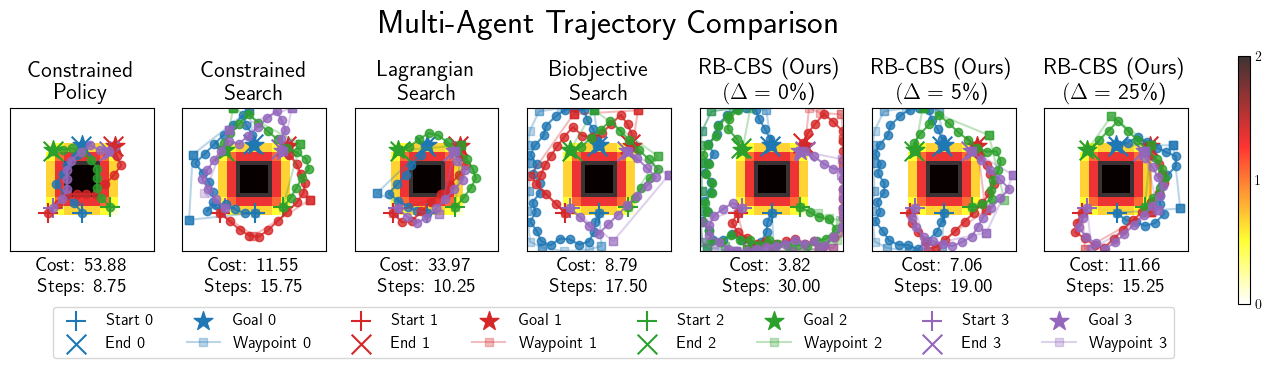

In [26]:
fig, axs = plt.subplots(1, 7, figsize=(16, 3.5))

for ax in axs.flat:
    ax.imshow(eval_env.get_map(), cmap="binary", interpolation="nearest", alpha=1.0, extent=[0, 1, 0, 1])
    cmap = ax.imshow(eval_env.get_cost_map(), cmap="hot_r", interpolation="nearest", alpha=0.8, extent=[0, 1, 0, 1])
    ax.set_xticks([])
    ax.set_yticks([])

cbar = plt.colorbar(cmap, ax=axs, orientation="vertical", fraction=0.01, pad=0.04)
cbar.ax.tick_params(size=0)
cbar.set_ticks([0, 1, 2])

RISK_PERCENTAGES = [0.0, 0.05, 0.25, 0.5]
deltas = [bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[i] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"]) for i in range(len(RISK_PERCENTAGES))]
delta_strings = [f"{deltas[i]:.2f}" for i in range(len(deltas))]
delta_percents = [f"{RISK_PERCENTAGES[i] * 100:.0f}\%" for i in range(len(RISK_PERCENTAGES))]  # type: ignore

methods_records_map = {
    "Constrained\nPolicy": (constrained_records, constrained_observations),
    "Constrained\nSearch": (constrained_search_records, constrained_search_observations, constrained_search_waypoints),
    "Lagrangian\nSearch": (lagrangian_search_records, lagrangian_search_observations, lagrangian_search_waypoints),
    "Biobjective\nSearch": (biobjective_search_records, biobjective_search_observations, biobjective_search_waypoints),
    "RB-CBS (Ours)\n 1": (rbu_search_records_0, rbu_search_observations_0, rbu_search_waypoints_0),
    "RB-CBS (Ours)\n 2": (rbu_search_records_1, rbu_search_observations_1, rbu_search_waypoints_1),
    "RB-CBS (Ours)\n 3": (rbu_search_records_2, rbu_search_observations_2, rbu_search_waypoints_2),  # type: ignore
}
titles = methods_records_map.keys()

for ax, title in zip(axs.flat, list(titles)):
    for agent_id in range(n_agents):
        ax = plot_agent_paths(
            agent_id,
            start[agent_id],
            goal[agent_id],
            np.array(methods_records_map[title][1][agent_id]),
            title,
            ax,
            wps=np.array(methods_records_map[title][2][agent_id]) if "Search" in title or "Ours" in title else None
        )
    if "Ours" in title:
        ax.set_title(title[:-2] + r"$(\Delta=$ " + delta_percents.pop(0) + ")", fontsize=16)
        # ax.set_title(title[:-2] + " (" + delta_percents.pop(0) + ")", fontsize=16)  # type: ignore
    # cc, reward = calculate_costs_and_rewards(methods_records_map[title][0], 
    #                                          methods_records_map[title][2] if "Search" in title else None)
    cc, reward = calculate_costs_and_rewards(methods_records_map[title][0])
    ax.text(0.5, -0.1, f"Cost: {cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=ax.transAxes, weight='bold', fontsize=14)
    ax.text(0.5, -0.25, f"Steps: {abs(reward):.2f}", horizontalalignment="center", verticalalignment="center", transform=ax.transAxes, weight='bold', fontsize=14)

plt.legend(loc="lower center", bbox_to_anchor=(-3, -0.8), ncol=8, fontsize=12)
_ = plt.suptitle("Multi-Agent Trajectory Comparison", fontsize=24)
plt.savefig("pud/plots/figures/paper/safe_multi_agent_pointenv_comparison.svg", bbox_inches="tight")